In [ ]:
!ls

Retail_Sales_data.csv  sample_data


In [ ]:
# Loading the Dataset

import pandas as pd
df = pd.read_csv(
    "/content/Retail_Sales_data.csv",
    encoding="latin1"
)
df.head()

,Order ID,Order Date,Customer ID,Customer Name,Segment,Country,Region,Product Category,Sub-Category,Product Name,Sales Amount,Quantity,Discount,Profit
0,AG-2011-2040,01-01-2011,TB-11280,Toby Braunhardt,Consumer,Algeria,Africa,Office Supplies,Storage,"Tenex Lockers, Blue",408.300,2,0.0,106.140
1,IN-2011-47883,01-01-2011,JH-15985,Joseph Holt,Consumer,Australia,Oceania,Office Supplies,Supplies,"Acme Trimmer, High Speed",120.366,3,0.1,36.036
2,HU-2011-1220,01-01-2011,AT-735,Annie Thurman,Consumer,Hungary,EMEA,Office Supplies,Storage,"Tenex Box, Single Width",66.120,4,0.0,29.640
3,IT-2011-3647632,01-01-2011,EM-14140,Eugene Moren,Home Office,Sweden,North,Office Supplies,Paper,"Enermax Note Cards, Premium",44.865,3,0.5,-26.055
4,IN-2011-47883,01-01-2011,JH-15985,Joseph Holt,Consumer,Australia,Oceania,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",113.670,5,0.1,37.770


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order ID          51290 non-null  object 
 1   Order Date        51290 non-null  object 
 2   Customer ID       51290 non-null  object 
 3   Customer Name     51290 non-null  object 
 4   Segment           51290 non-null  object 
 5   Country           51290 non-null  object 
 6   Region            51290 non-null  object 
 7   Product Category  51290 non-null  object 
 8   Sub-Category      51290 non-null  object 
 9   Product Name      51290 non-null  object 
 10  Sales Amount      51290 non-null  float64
 11  Quantity          51290 non-null  int64  
 12  Discount          51290 non-null  float64
 13  Profit            51290 non-null  float64
dtypes: float64(3), int64(1), object(10)
memory usage: 5.5+ MB


,Sales Amount,Quantity,Discount,Profit
count,51290.000000,51290.000000,51290.000000,51290.000000
mean,246.490581,3.476545,0.142908,28.610982
std,487.565361,2.278766,0.212280,174.340972
min,0.444000,1.000000,0.000000,-6599.978000
25%,30.758625,2.000000,0.000000,0.000000
50%,85.053000,3.000000,0.000000,9.240000
75%,251.053200,5.000000,0.200000,36.810000
max,22638.480000,14.000000,0.850000,8399.976000


# **Phase 1: Data Cleaning & Preparation**

In [ ]:
# Handling missing values
df.isnull().sum()

,0
Order ID,0
Order Date,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
Region,0
Product Category,0
Sub-Category,0
Product Name,0


In [ ]:
# Duplicate Handling

print(" Duplicate Rows : ",df.duplicated().sum())
df=df.drop_duplicates()
print("After removing : ",len(df))      # Before 51290

 Duplicate Rows :  9
After removing :  51281


In [ ]:
# Converting Order Date

df['Order Date'] = pd.to_datetime(df['Order Date'],dayfirst=True)
df['Order Date'].head(-1)

,Order Date
0,2011-01-01
1,2011-01-01
2,2011-01-01
3,2011-01-01
4,2011-01-01
...,...
51284,2014-12-31
51285,2014-12-31
51286,2014-12-31
51287,2014-12-31


In [ ]:
# Profit Margin
import numpy as np

df['Profit Margin'] = round(df['Profit']/df['Sales Amount'],2)*100

df["Profit Margin"] = df["Profit Margin"].replace(
    [np.inf, -np.inf],np.nan)
df['Profit Margin'].head(-1)


,Profit Margin
0,26.0
1,30.0
2,45.0
3,-58.0
4,33.0
...,...
51284,4.0
51285,32.0
51286,11.0
51287,47.0


In [ ]:
df["Month"] = df["Order Date"].dt.month
df["Year"]= df["Order Date"].dt.year
df["Quater"]=df["Order Date"].dt.quarter

In [ ]:
df.to_csv(
    "/content/SalesPulse_Cleaned.csv",
    index=False
)

# **Phase 2: Exploratory Data Analysis (EDA)**

In [ ]:
total_sales=df["Sales Amount"].sum()
total_profit=df["Profit"].sum()
total_quantity=df["Quantity"].sum()
print("Total Sales : ",round(total_sales,2))
print("Total Profit : ",round(total_profit,2))
print("Total Quantity : ",total_quantity)

total_order=df["Order ID"].nunique()
print("Total Orders : ",total_order)

Total Sales :  12641024.34
Total Profit :  1467298.33
Total Quantity :  178290
Total Orders :  25035


In [ ]:
# Top 10 Best-Selling Products

top_products = (
    df.groupby("Product Name")["Sales Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(round(top_products,3))

Product Name
Apple Smart Phone, Full Size                                86935.779
Cisco Smart Phone, Full Size                                76441.531
Motorola Smart Phone, Full Size                             73156.303
Nokia Smart Phone, Full Size                                71904.556
Canon imageCLASS 2200 Advanced Copier                       61599.824
Hon Executive Leather Armchair, Adjustable                  58193.484
Office Star Executive Leather Armchair, Adjustable          50661.684
Harbour Creations Executive Leather Armchair, Adjustable    50121.516
Samsung Smart Phone, Cordless                               48653.460
Nokia Smart Phone, with Caller ID                           47877.786
Name: Sales Amount, dtype: float64


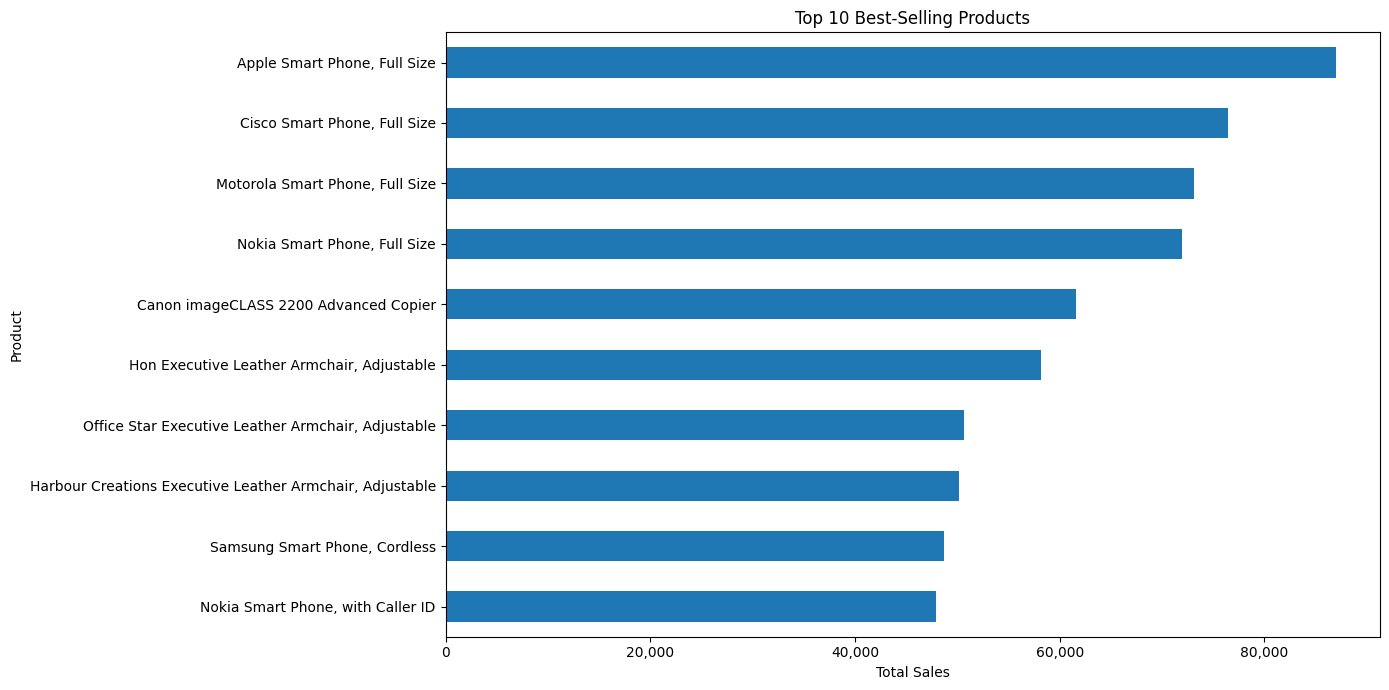

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

plt.figure(figsize=(14,7))


ax = top_products.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Total Sales")
plt.ylabel("Product")

ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

Apple Smart Phone, Full Size has the highest-sales product

In [ ]:
# Product Category Performance

category_sales = (
    df.groupby("Product Category")["Sales Amount"].sum().sort_values(ascending=False)
    )

print(category_sales.apply(lambda x: f'{x:,.2f}'))

Product Category
Technology         4,744,500.74
Furniture          4,109,633.74
Office Supplies    3,786,889.86
Name: Sales Amount, dtype: object


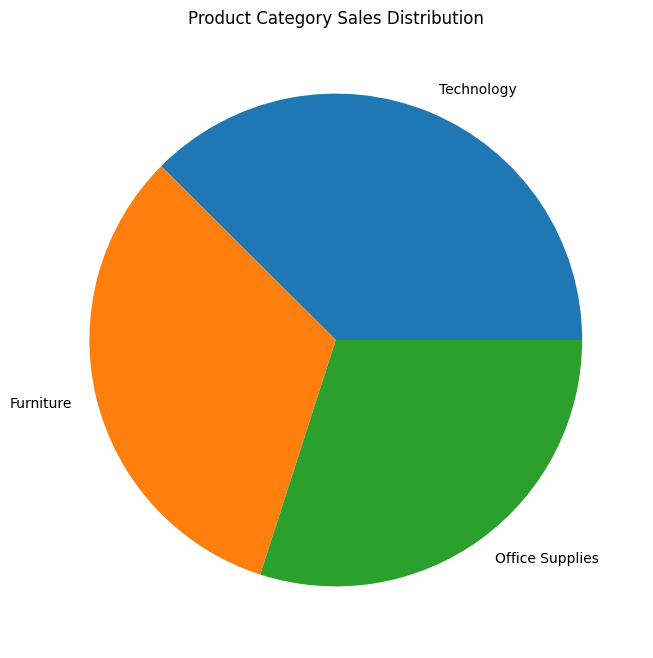

In [ ]:
plt.figure(figsize=(8, 8))

plt.pie(
    category_sales,
    labels=category_sales.index,

)

plt.title("Product Category Sales Distribution")
plt.show()

Region
Central           2,822,265.44
South             1,600,207.83
North             1,248,165.60
Oceania           1,100,145.79
Southeast Asia      884,079.34
North Asia          848,309.78
EMEA                806,161.31
Africa              783,695.96
Central Asia        752,826.57
West                725,457.82
East                678,499.87
Caribbean           324,280.86
Canada               66,928.17
Name: Sales Amount, dtype: object


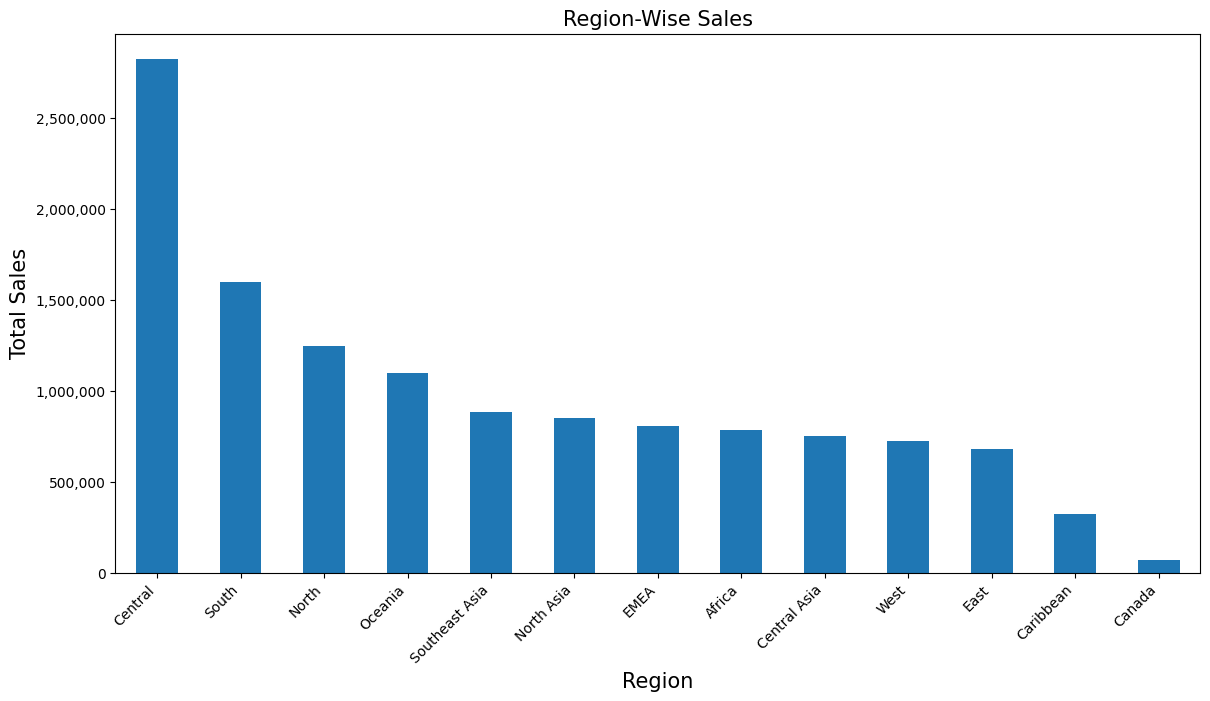

In [ ]:
# Region-Wise Sales

import matplotlib.ticker as ticker

region_sales=(
    df.groupby("Region")["Sales Amount"].sum().sort_values(ascending=False)
)
print(region_sales.apply(lambda x: f'{x:,.2f}'))

plt.figure(figsize=(14,7))
ax = region_sales.plot(kind="bar")
plt.title("Region-Wise Sales",fontsize=15)
plt.xlabel("Region",fontsize=15)
plt.ylabel("Total Sales",fontsize=15  )
plt.xticks(rotation=45,ha='right',fontsize=10)

ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.show()

Highest-performing region is currently : Central

In [ ]:
monthly_sales = (
    df.groupby("Month")["Sales Amount"]
    .sum()
)
print(monthly_sales.apply(lambda x: f'{x:,.2f}'))


Month
1       675,133.67
2       543,718.89
3       770,500.94
4       698,279.84
5       903,996.95
6     1,269,609.35
7       749,381.84
8     1,293,739.33
9     1,437,380.11
10    1,168,184.39
11    1,550,933.51
12    1,580,165.53
Name: Sales Amount, dtype: object


In [ ]:
monthly_sales = (
    df.groupby(
        df["Order Date"].dt.to_period("M")
    )["Sales Amount"]
    .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

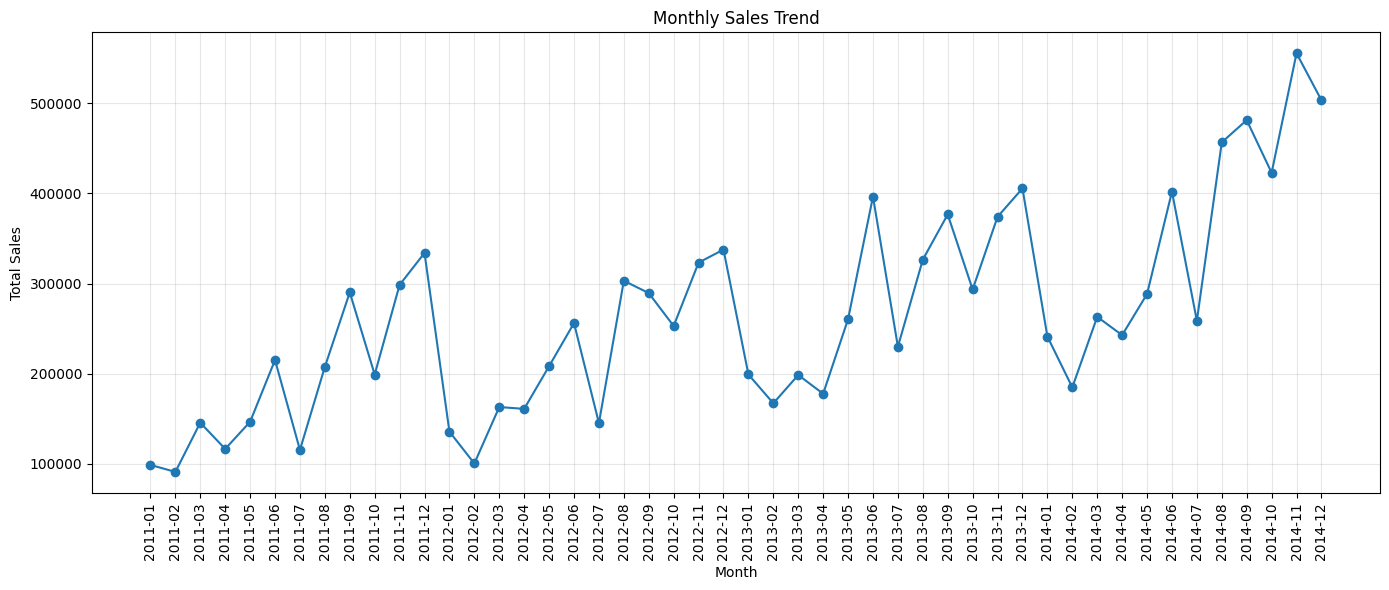

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=90)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Highest Sales Month - November 2014 (555,279)

# **Phase 3: Business Insights**

In [ ]:
# Average Order Value

order_sales = (
    df.groupby("Order ID")["Sales Amount"]
    .sum()
)

average_order_value = order_sales.mean()

print(
    "Average Order Value:",
    round(average_order_value, 2)
)

Average Order Value: 504.93


In [ ]:
# Repeat Customer Percentage

customer_order=(df.groupby("Customer ID")["Order ID"].nunique())  # Unique  ID

repeated_customer=(customer_order[customer_order > 1]).count()
total_customer=customer_order.count()

percentage=(repeated_customer/total_customer)*100
print("Repeat Customer Percentage : ",round(percentage,2))

Repeat Customer Percentage :  99.37


In [ ]:
# Highest Performing Region

highest_region = region_sales.idxmax()

highest_region_sales = region_sales.max()

print("Best Region:", highest_region)
print("Sales:",round(highest_region_sales, 2))

Best Region: Central
Sales: 2822265.44


In [ ]:
# Best Category

best_category = category_sales.idxmax()

print("Best Category:", best_category)

Best Category: Technology


In [ ]:
# Customer Purchase Frequency

purchase_frequency = (
    df.groupby("Customer ID")["Order ID"]
    .nunique()
)

top_frequent_customers = (
    purchase_frequency
    .sort_values(ascending=False)
    .head(10)
)

print(top_frequent_customers)

Customer ID
PO-18850    41
MP-17965    39
KH-16690    39
CK-12205    38
AR-10825    38
JH-15985    38
WB-21850    38
ZC-21910    37
TP-21130    37
NS-18640    37
Name: Order ID, dtype: int64


In [ ]:
# Low-performing products

low_products = (
    df.groupby("Product Name")["Sales Amount"]
    .sum()
    .sort_values(ascending=True)
    .head(5)
)

print(low_products)

Product Name
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac    1.624
Avery 5                                                             5.760
Xerox 20                                                            6.480
Grip Seal Envelopes                                                 7.072
Avery Hi-Liter Pen Style Six-Color Fluorescent Set                  7.700
Name: Sales Amount, dtype: float64


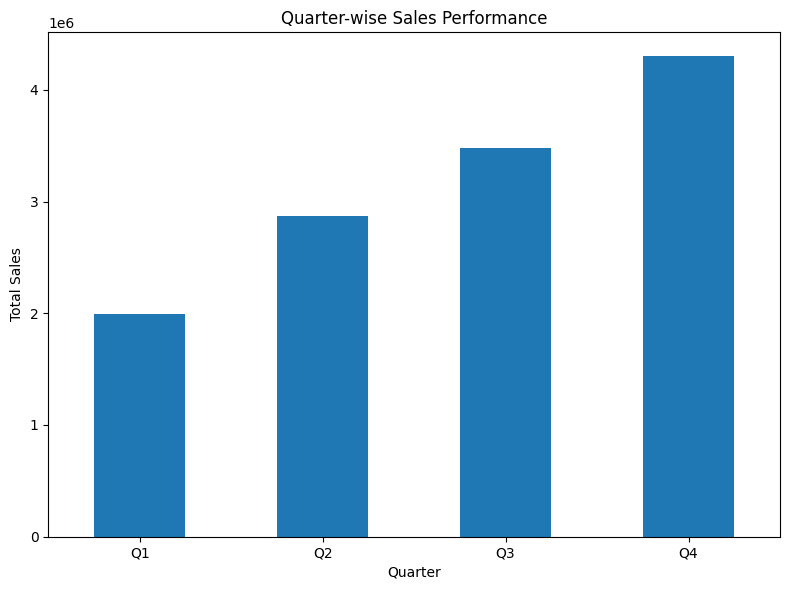

In [ ]:
# Seasonal sales patterns [Quater]

quater_sales = (
    df.groupby("Quater")["Sales Amount"]
    .sum()
)

# print(quarter_sales)

plt.figure(figsize=(8, 6))

quater_sales.plot(kind="bar")

plt.title("Quarter-wise Sales Performance")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.xticks(
    ticks=[0, 1, 2, 3],
    labels=["Q1", "Q2", "Q3", "Q4"],
    rotation=0
)

plt.tight_layout()
plt.show()

Q4 generates the highest sales, indicating stronger year-end purchasing activity

# **Phase 4: Customer Segmentation**

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Customer Level Database

customer_data=df.groupby("Customer Name").agg(
    total_purchase_value=("Sales Amount","sum"),
    purchase_frequency=("Order ID","nunique"),
    avg_order_value=("Sales Amount","mean")
)
customer_data.head()

,total_purchase_value,purchase_frequency,avg_order_value
Customer Name,,,
Aaron Bergman,24644.62750,37,276.905927
Aaron Hawkins,20759.51384,34,370.705604
Aaron Smayling,14212.62840,31,236.877140
Adam Bellavance,20186.77840,41,296.864388
Adam Hart,21718.20142,42,258.550017


In [ ]:
features=[
    "total_purchase_value",
    "purchase_frequency",
    "avg_order_value"
]
X=customer_data[features]
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

X_scaled

array([[ 1.67968698,  0.8523629 ,  0.49672145],
       [ 0.93336965,  0.29723305,  2.01625165],
       [-0.32426513, -0.2578968 , -0.15173442],
       ...,
       [ 0.81904597, -0.2578968 ,  1.84409002],
       [ 2.41644771,  1.03740618,  1.43878166],
       [-0.66659251, -0.62798337, -0.25997121]])

In [ ]:
inertia = []

for k in range(2, 9):

    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
inertia

[1439.0275582836043,
 1074.6794491924445,
 877.7032633882176,
 718.055100781356,
 636.9259907253287,
 563.612200792226,
 498.1030646309204]

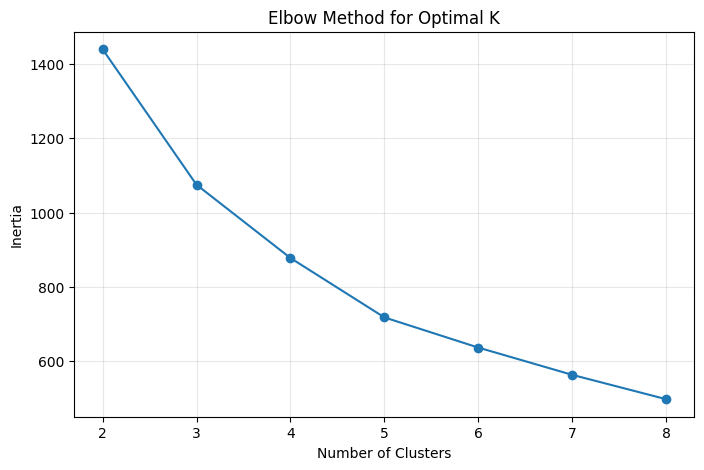

In [ ]:
# K-mean clustering using Elbow Method

plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 9),
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.grid(True, alpha=0.3)

plt.show()

Massive drop at k = 3

In [ ]:
kmeans = KMeans(n_clusters=3,random_state=42,n_init=10)

customer_data["Cluster"] = kmeans.fit_predict(X_scaled)

customer_data.head(10)

,total_purchase_value,purchase_frequency,avg_order_value,Cluster
Customer Name,,,,
Aaron Bergman,24644.62750,37,276.905927,1
Aaron Hawkins,20759.51384,34,370.705604,1
Aaron Smayling,14212.62840,31,236.877140,2
Adam Bellavance,20186.77840,41,296.864388,1
Adam Hart,21718.20142,42,258.550017,1
Adam Shillingsburg,15444.67672,36,217.530658,0
Adrian Barton,25123.18000,40,326.275065,1
Adrian Hane,11405.91788,26,211.220701,2
Adrian Shami,11286.05420,24,256.501232,2


Cluster 0 = High Value

Cluster 1 = Regular

Cluster 2 = Occasional





In [ ]:
cluster_profile = (customer_data.groupby("Cluster")[features].mean())

print(cluster_profile)

         total_purchase_value  purchase_frequency  avg_order_value
Cluster                                                           
0                15476.998710           36.464684       216.744967
1                22811.011359           34.725389       320.136636
2                12237.797287           27.753754       227.245963


In [ ]:
cluster_rank=(cluster_profile["total_purchase_value"].rank(ascending=False,method="first"))

cluster_labels = {}

for cluster, rank in cluster_rank.items():

    if rank == 1:
        cluster_labels[cluster] = "High Value"

    elif rank == 2:
        cluster_labels[cluster] = "Regular"

    else:
        cluster_labels[cluster] = "Occasional"


customer_data["Customer Segment"] = (
    customer_data["Cluster"]
    .map(cluster_labels)
)
customer_data.head()

,total_purchase_value,purchase_frequency,avg_order_value,Cluster,Customer Segment
Customer Name,,,,,
Aaron Bergman,24644.62750,37,276.905927,1,High Value
Aaron Hawkins,20759.51384,34,370.705604,1,High Value
Aaron Smayling,14212.62840,31,236.877140,2,Occasional
Adam Bellavance,20186.77840,41,296.864388,1,High Value
Adam Hart,21718.20142,42,258.550017,1,High Value


In [ ]:
# Counting each element in the Customer Segment

customer_segment_counts = customer_data["Customer Segment"].value_counts()

print(customer_segment_counts)

Customer Segment
Occasional    333
Regular       269
High Value    193
Name: count, dtype: int64


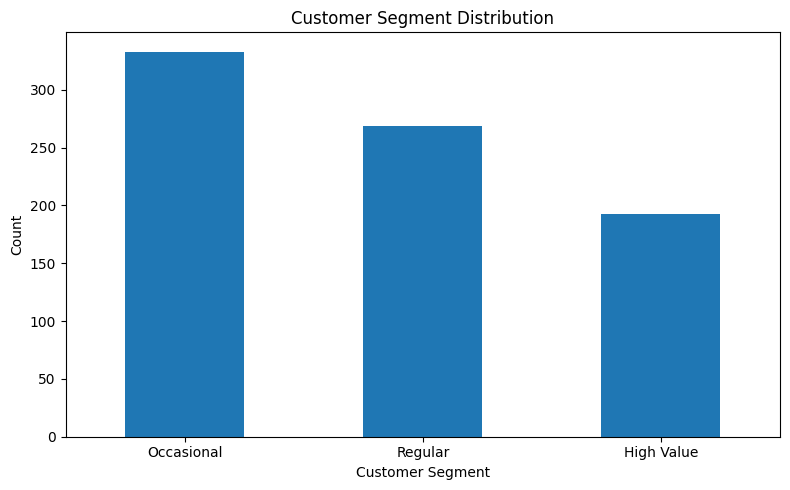

In [ ]:
# Customer Segment Distribution

import matplotlib.ticker as ticker

plt.figure(figsize=(8,5))

customer_segment_counts.plot(kind="bar")

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

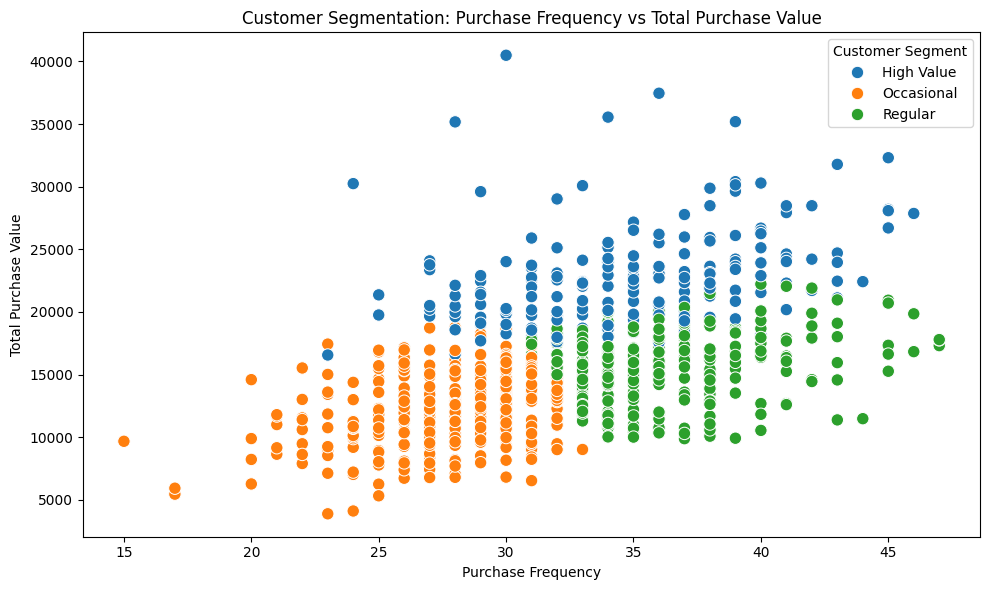

In [ ]:
# Customer Segment Scatter Plot

import seaborn as sns
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=customer_data,
    x="purchase_frequency",
    y="total_purchase_value",
    hue="Customer Segment",
    s=80
)

plt.title("Customer Segmentation: Purchase Frequency vs Total Purchase Value")

plt.xlabel("Purchase Frequency")
plt.ylabel("Total Purchase Value")

plt.tight_layout()
plt.show()

# **PHASE 5 — SalesPulse Dashboard**

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, Markdown

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

In [ ]:
# Load Clean CSV file

DATA_PATH = 'SalesPulse_Cleaned.csv'
sales = pd.read_csv(DATA_PATH)

if 'Order Date' in sales.columns:
    sales['Order Date'] = pd.to_datetime(sales['Order Date'], errors='coerce')

print(f'Dataset shape: {sales.shape[0]:,} rows × {sales.shape[1]} columns')
display(sales.head())

Dataset shape: 51,281 rows × 18 columns


,Order ID,Order Date,Customer ID,Customer Name,Segment,Country,Region,Product Category,Sub-Category,Product Name,Sales Amount,Quantity,Discount,Profit,Profit Margin,Month,Year,Quater
0,AG-2011-2040,2011-01-01,TB-11280,Toby Braunhardt,Consumer,Algeria,Africa,Office Supplies,Storage,"Tenex Lockers, Blue",408.30,2,0.00,106.14,26.00,1,2011,1
1,IN-2011-47883,2011-01-01,JH-15985,Joseph Holt,Consumer,Australia,Oceania,Office Supplies,Supplies,"Acme Trimmer, High Speed",120.37,3,0.10,36.04,30.00,1,2011,1
2,HU-2011-1220,2011-01-01,AT-735,Annie Thurman,Consumer,Hungary,EMEA,Office Supplies,Storage,"Tenex Box, Single Width",66.12,4,0.00,29.64,45.00,1,2011,1
3,IT-2011-3647632,2011-01-01,EM-14140,Eugene Moren,Home Office,Sweden,North,Office Supplies,Paper,"Enermax Note Cards, Premium",44.87,3,0.50,-26.05,-58.00,1,2011,1
4,IN-2011-47883,2011-01-01,JH-15985,Joseph Holt,Consumer,Australia,Oceania,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",113.67,5,0.10,37.77,33.00,1,2011,1


In [ ]:
# Dashboard data preparation

if 'Order Date' in sales.columns:
    sales['Year'] = sales['Order Date'].dt.year
    sales['Month Number'] = sales['Order Date'].dt.month
    sales['Month Name'] = sales['Order Date'].dt.strftime('%b')
    sales['Month Period'] = sales['Order Date'].dt.to_period('M').astype(str)
    sales['Quarter'] = 'Q' + sales['Order Date'].dt.quarter.astype(str)

SALES_COL = 'Sales Amount'
PROFIT_COL = 'Profit' if 'Profit' in sales.columns else None
QTY_COL = 'Quantity' if 'Quantity' in sales.columns else None

required = ['Order ID', SALES_COL]
missing = [c for c in required if c not in sales.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')

print('Dashboard-ready dataset:', sales.shape)
print('Available columns:', list(sales.columns))

Dashboard-ready dataset: (51281, 22)
Available columns: ['Order ID', 'Order Date', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'Region', 'Product Category', 'Sub-Category', 'Product Name', 'Sales Amount', 'Quantity', 'Discount', 'Profit', 'Profit Margin', 'Month', 'Year', 'Quater', 'Month Number', 'Month Name', 'Month Period', 'Quarter']


In [ ]:
# KPI dashboard

total_sales = sales[SALES_COL].sum()
total_profit = sales[PROFIT_COL].sum() if PROFIT_COL else np.nan
total_orders = sales['Order ID'].nunique()
total_customers = sales['Customer ID'].nunique() if 'Customer ID' in sales.columns else np.nan
aov = total_sales / total_orders if total_orders else np.nan
profit_margin = (total_profit / total_sales * 100) if PROFIT_COL and total_sales else np.nan

fig = make_subplots(rows=1, cols=5, specs=[[{'type':'indicator'}]*5], horizontal_spacing=0.04)
values = [total_sales, total_profit, total_orders, total_customers, aov]
titles = ['Total Sales','Total Profit','Orders','Customers','Average Order Value']
formats = [',.2f',',.2f',',.0f',',.0f',',.2f']
for i, (v,t,f) in enumerate(zip(values,titles,formats),1):
    fig.add_trace(go.Indicator(mode='number', value=v, number={'valueformat':f}, title={'text':t}), row=1, col=i)
fig.update_layout(title='SalesPulse Executive KPI Dashboard', height=180, margin=dict(l=15,r=15,t=55,b=10))
fig.show()

print(f'Profit margin: {profit_margin:.2f}%') if PROFIT_COL else None

Profit margin: 11.61%


In [ ]:
# Monthly Sales Trend

monthly_sales = sales.groupby('Month Period', as_index=False)[SALES_COL].sum().sort_values('Month Period')
fig = px.line(monthly_sales, x='Month Period', y=SALES_COL, markers=True,
              title='Monthly Sales Trend', labels={'Month Period':'Month', SALES_COL:'Sales Amount'})
fig.update_traces(hovertemplate='Month: %{x}<br>Sales: %{y:,.2f}<extra></extra>')
fig.update_layout(height=500, hovermode='x unified')
fig.show()
# display(monthly_sales)

In [ ]:
# Region-wise Sales

region_sales = sales.groupby('Region', as_index=False).agg(
    Sales=(SALES_COL,'sum'), Orders=('Order ID','nunique')
).sort_values('Sales', ascending=False)

fig = px.bar(region_sales, x='Region', y='Sales', text='Sales',
             title='Region-wise Sales Comparison', labels={'Sales':'Total Sales'})
fig.update_traces(texttemplate='%{text:,.0f}', textposition='outside')
fig.update_layout(height=500)
fig.show()
# display(region_sales)

In [ ]:
# Product Category Performance

agg_qty = (QTY_COL, 'sum') if QTY_COL else ('Order ID','size')
category_sales = sales.groupby('Product Category', as_index=False).agg(
    Sales=(SALES_COL,'sum'), Quantity=agg_qty
).sort_values('Sales', ascending=False)

fig = px.bar(category_sales, x='Product Category', y='Sales', color='Product Category',
             text='Sales', title='Product Category Performance', labels={'Sales':'Total Sales'})
fig.update_traces(texttemplate='%{text:,.0f}', textposition='outside')
fig.update_layout(height=500, showlegend=False)
fig.show()
# display(category_sales)

In [ ]:
# Top Products

top_products = sales.groupby('Product Name', as_index=False).agg(
    Sales=(SALES_COL,'sum'), Quantity=agg_qty
).sort_values('Sales', ascending=False).head(10).sort_values('Sales')

fig = px.bar(top_products, x='Sales', y='Product Name', orientation='h', text='Sales',
             title='Top 10 Revenue-Generating Products', labels={'Sales':'Total Sales'})
fig.update_traces(texttemplate='%{text:,.0f}', textposition='outside')
fig.update_layout(height=550)
fig.show()
# display(top_products.sort_values('Sales', ascending=False))

In [ ]:
# Customer Segmentation

segment_candidates = ['Customer Segment','Customer_Segment','Segment','Cluster Segment','Cluster_Segment','Customer Cluster']
SEGMENT_COLUMN = next((c for c in segment_candidates if c in sales.columns), None)
print('Detected segment column:', SEGMENT_COLUMN)

if SEGMENT_COLUMN:
    segment_summary = sales.groupby(SEGMENT_COLUMN, as_index=False).agg(
        Sales=(SALES_COL,'sum'), Orders=('Order ID','nunique'),
        Customers=('Customer ID','nunique') if 'Customer ID' in sales.columns else ('Order ID','nunique')
    ).sort_values('Sales', ascending=False)
    fig = px.bar(segment_summary, x=SEGMENT_COLUMN, y='Sales', color=SEGMENT_COLUMN,
                 text='Sales', title='Customer Segment Sales Contribution')
    fig.update_traces(texttemplate='%{text:,.0f}', textposition='outside')
    fig.update_layout(height=500, showlegend=False)
    fig.show()
else:
    print('No segment column detected. Run Phase 4 first or set SEGMENT_COLUMN to the Phase 4 column name.')

Detected segment column: Segment


In [ ]:
if SEGMENT_COLUMN:
    segment_counts = sales[SEGMENT_COLUMN].value_counts(dropna=False).reset_index()
    segment_counts.columns = [SEGMENT_COLUMN,'Records']
    fig = px.pie(segment_counts, names=SEGMENT_COLUMN, values='Records', hole=0.45,
                 title='Customer Segment Distribution')
    fig.update_layout(height=500)
    fig.show()

## **Key Findings**

In [ ]:
best_month = monthly_sales.loc[monthly_sales[SALES_COL].idxmax(),'Month Period']
best_month_sales = monthly_sales[SALES_COL].max()
best_region = region_sales.iloc[0]['Region']
best_region_sales = region_sales.iloc[0]['Sales']
best_category = category_sales.iloc[0]['Product Category']
best_category_sales = category_sales.iloc[0]['Sales']
best_product = top_products.iloc[-1]['Product Name']

findings = [
    f'Highest-sales month: {best_month}, with sales of {best_month_sales:,.2f}.',
    f'Highest-performing region: {best_region}, contributing {best_region_sales:,.2f} in sales.',
    f'Highest-performing product category: {best_category}, contributing {best_category_sales:,.2f} in sales.',
    f'Top revenue-generating product: {best_product}.',
    f'The dataset contains {total_orders:,} unique orders.'
]
if not np.isnan(total_customers):
    findings.append(f'The dataset contains {total_customers:,.0f} unique customers.')

for i, finding in enumerate(findings, 1):
    print(f'{i}. {finding}')

1. Highest-sales month: 2014-11, with sales of 555,279.03.
2. Highest-performing region: Central, contributing 2,822,265.44 in sales.
3. Highest-performing product category: Technology, contributing 4,744,500.74 in sales.
4. Top revenue-generating product: Apple Smart Phone, Full Size.
5. The dataset contains 25,035 unique orders.
6. The dataset contains 1,590 unique customers.


## **Business Recommendations**

1. **Prioritize high-performing regions:** protect inventory availability and marketing coverage in the strongest regions while investigating weaker regional performance.
2. **Strengthen high-performing categories:** maintain stock and targeted promotions for categories that consistently generate strong sales and profit.
3. **Promote high-value products:** use the top-product ranking to support merchandising, cross-selling, and promotional campaigns.
4. **Focus on Technology:** Since Technology is the highest-revenue category
5. **Monitor seasonality:** use the monthly trend for inventory, campaign, and staffing planning.


## **Growth Opportunities**

- Increase repeat purchases through customer-segment-based campaigns.
- Build cross-selling strategies around high-selling products and categories.
- Investigate underperforming regions and categories for pricing, assortment, and promotional opportunities.
- Use seasonal sales patterns for demand planning and inventory optimization.
- Track profit margin alongside revenue so growth remains commercially sustainable.
- Future extensions: sales forecasting, cohort analysis, and customer lifetime value.

# **Business Report**

**Key Insights**


*   Technology leads category sales
*   Central is the strongest region

*   Smartphones dominate top products
*   Repeat purchasing is extremely high



**Customer Behavior**


*   **High Customer Retention:**
A very high percentage of customers place more than one order, indicating strong repeat-purchase behavior
*   **High-Value Customers:** Drive Revenue
A smaller group of customers can contribute significantly more revenue through higher purchase values and greater purchase frequency


*   **Occasional Customers:** Have Growth Potential
Customers who purchase less frequently can be targeted with discounts, product recommendations, and promotional campaigns to encourage repeat purchases
*   **Customer Purchase Frequency:** Matters
Customers with frequent purchases represent an important opportunity for loyalty programs, personalized offers, and targeted promotions




**Product Performance**


*   Technology is the Best-Performing Category
*   Furniture Shows Strong Sales Contribution


*   Top Products Contribute Significantly to Revenue
*   Office Supplies Have Lower Overall Sales





**Strategic Recommendations**



*   Focus on High-Performing Products
*   Strengthen the Technology Category
*   Use Seasonal Trends for Planning
*   Expand Sales in Lower-Performing Regions

